In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
file_path="/content/drive/MyDrive/Python/insurance.csv"

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
)

In [8]:
df = pd.read_csv(file_path)
print("First 5 Rows")
print(df.head())

First 5 Rows
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [9]:


print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())





Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows
1


In [10]:
print("\nDescriptive Statistics")
print(df.describe())
print("\nAverage Insurance Charges:", df['charges'].mean())
print("Average Age:", df['age'].mean())
print("Average BMI:", df['bmi'].mean())
print("Average Children:", df['children'].mean())


Descriptive Statistics
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Average Insurance Charges: 13270.422265141257
Average Age: 39.20702541106129
Average BMI: 30.66339686098655
Average Children: 1.0949177877429


In [11]:
df = df.drop_duplicates()

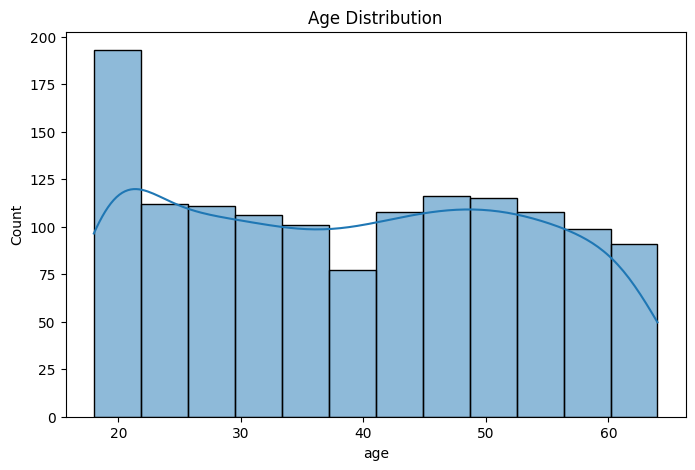

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()



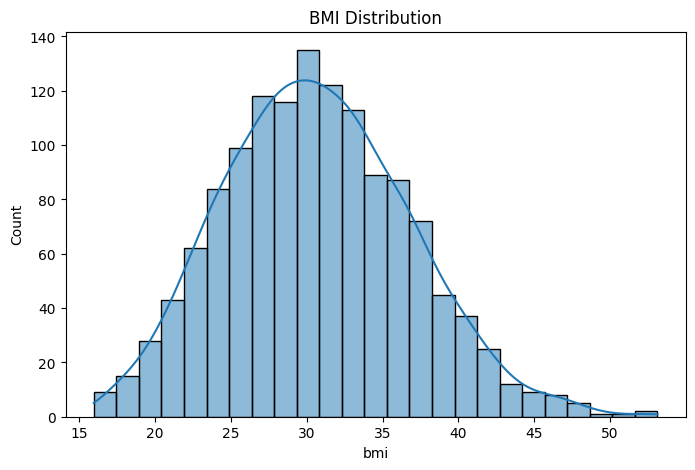

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.title("BMI Distribution")
plt.show()

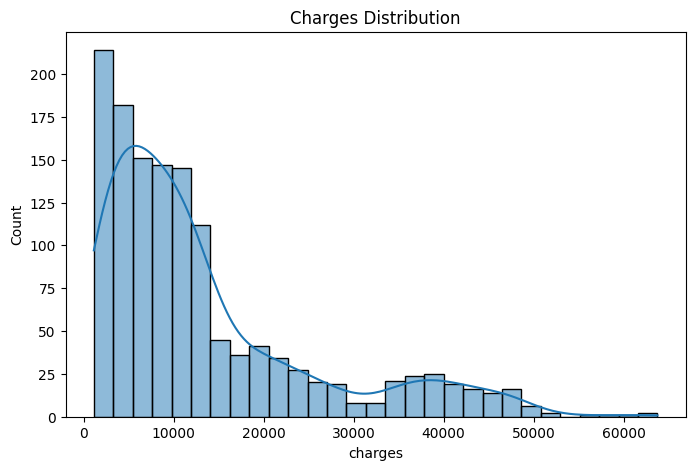

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Charges Distribution")
plt.show()

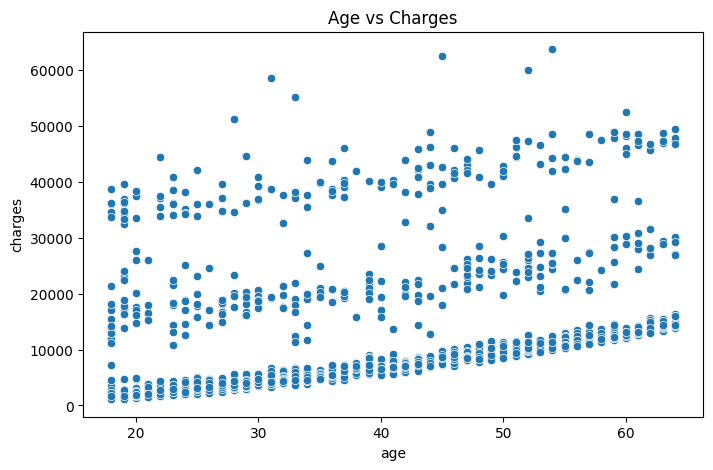

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")
plt.show()


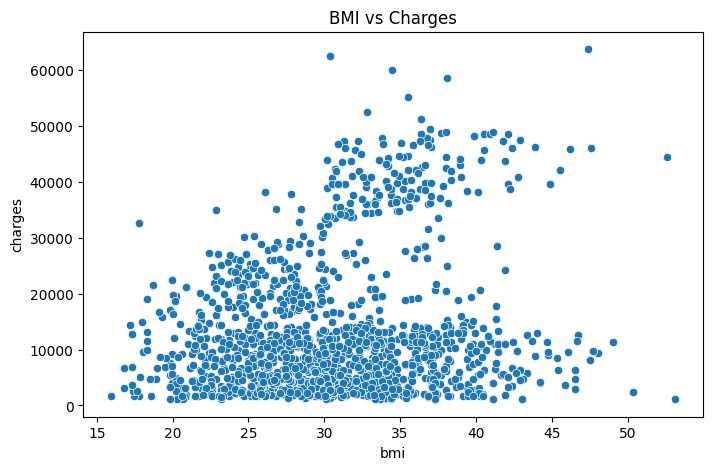

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")
plt.show()

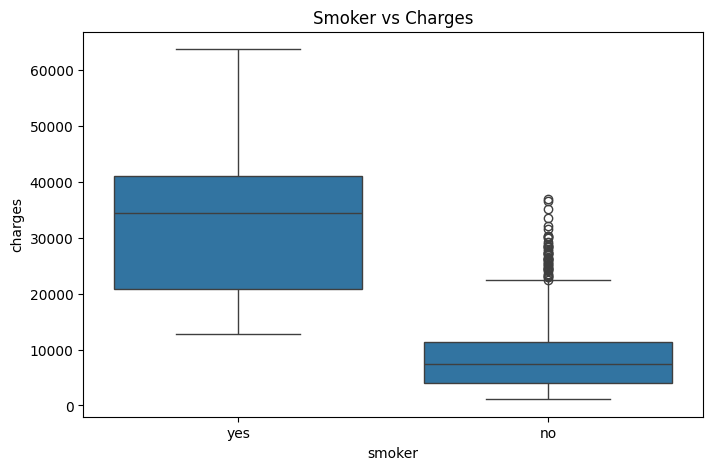

In [17]:

plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Charges")
plt.show()

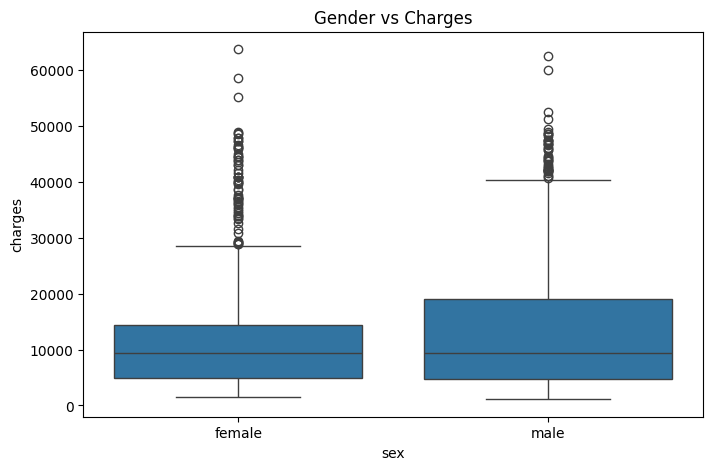

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Gender vs Charges")
plt.show()


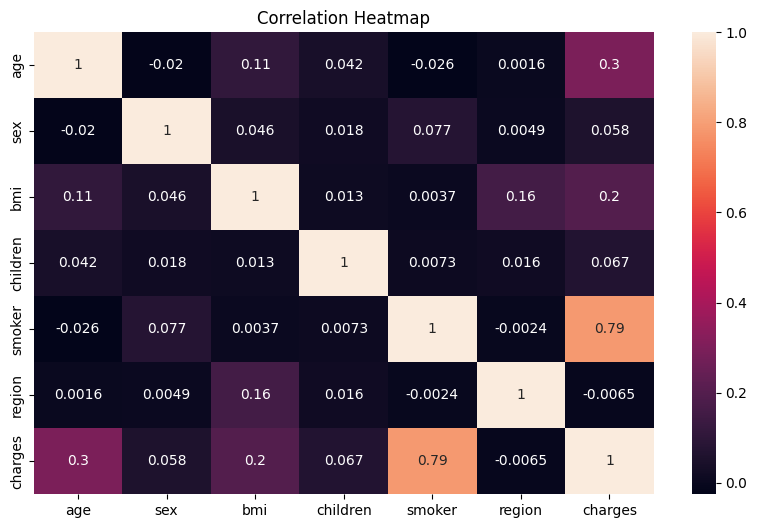

In [19]:
temp_df = df.copy()

le = LabelEncoder()

temp_df['sex'] = le.fit_transform(temp_df['sex'])
temp_df['smoker'] = le.fit_transform(temp_df['smoker'])
temp_df['region'] = le.fit_transform(temp_df['region'])

plt.figure(figsize=(10,6))
sns.heatmap(temp_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])


In [21]:
X = df[['age']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

y_pred = simple_model.predict(X_test)

print("\n===== Simple Linear Regression =====")

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


===== Simple Linear Regression =====
R2 Score: 0.09513000782072023
MAE: 9657.78934976123
MSE: 166275348.23176482
RMSE: 12894.779883028823


In [22]:
X_multi = df[['age', 'bmi', 'children', 'smoker']]
y_multi = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print("\n===== Multiple Linear Regression =====")

print("R2 Score:", r2_score(y_test, y_pred_multi))
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))



===== Multiple Linear Regression =====
R2 Score: 0.8045531086669288
MAE: 4198.592612356366
MSE: 35914551.48043363
RMSE: 5992.875059638206


In [23]:
median_charge = df['charges'].median()

df['insurance_category'] = np.where(
    df['charges'] >= median_charge,
    1,
    0
)

X_log = df[['age', 'bmi', 'children', 'smoker']]
y_log = df['insurance_category']

X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y_log,
    test_size=0.2,
    random_state=42
)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n===== Logistic Regression =====")

print("Accuracy Score:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))



===== Logistic Regression =====
Accuracy Score: 0.8992537313432836

Confusion Matrix
[[115  17]
 [ 10 126]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       132
           1       0.88      0.93      0.90       136

    accuracy                           0.90       268
   macro avg       0.90      0.90      0.90       268
weighted avg       0.90      0.90      0.90       268



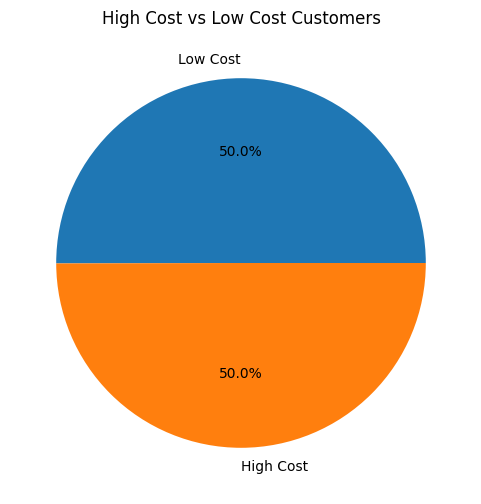

In [24]:
category_count = df['insurance_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    category_count,
    labels=['Low Cost', 'High Cost'],
    autopct='%1.1f%%'
)

plt.title("High Cost vs Low Cost Customers")
plt.show()


In [25]:
print("\n===== Insights =====")

print("1. Smokers generally have higher insurance charges.")
print("2. Age and BMI positively affect insurance costs.")
print("3. Multiple Linear Regression performs better than Simple Linear Regression.")
print("4. Logistic Regression helps classify high-risk customers.")
print("5. Insurance companies can use this system for premium estimation.")



===== Insights =====
1. Smokers generally have higher insurance charges.
2. Age and BMI positively affect insurance costs.
3. Multiple Linear Regression performs better than Simple Linear Regression.
4. Logistic Regression helps classify high-risk customers.
5. Insurance companies can use this system for premium estimation.
